# 项目二：手写数字识别（监督学习巩固）

**目标**：给一张 8×8 的手写数字图片，让模型判断它是 0–9 中的哪一个。

**和鸢尾花相比，这里多学了什么**：
- 理解「图片其实就是一堆数字」（每个像素是一个特征）
- 混淆矩阵怎么用来找「模型容易搞混哪两个数字」
- 多模型对比，体会「模型要匹配数据」
- 用 PCA 把 64 维降到 2 维可视化 → 为无监督学习埋个引子

> 从上到下，逐个代码块按 `Shift + Enter` 运行。

In [4]:
# 第 1 步：导入库 + 加载数据
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC                          # 支持向量机，很适合图像
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

digits = load_digits()
X = digits.data      # 每张图 64 个像素值（8×8 展开成一行）
y = digits.target    # 0-9 的数字

print("特征 X 的形状:", X.shape)   # (1797, 64) = 1797 张图，每张 64 个像素
print("标签 y 的形状:", y.shape)
print("数字种类:", digits.target_names)

特征 X 的形状: (1797, 64)
标签 y 的形状: (1797,)
数字种类: [0 1 2 3 4 5 6 7 8 9]


## 图片其实就是一堆数字

这张 8×8 的手写数字图，计算机眼里不是「图」，而是 **64 个数字**：

- 每个数字是一个像素的灰度值
- `0` 表示纯白（没墨水），`16` 表示纯黑（有墨水）

所以「识别数字」这件事，本质上和「分类鸢尾花」是**同一个问题**：给一堆数字特征，判断属于哪一类。区别只是——鸢尾花是 4 个特征，这里是 64 个特征。

c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 24352 (\N{CJK UNIFIED IDEOGRAPH-5F20}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

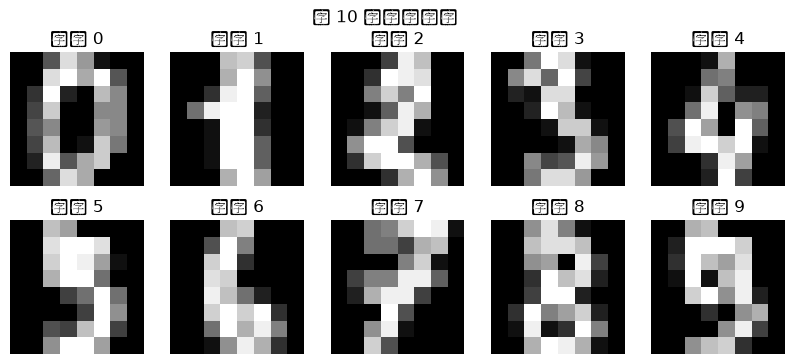

In [3]:
# 第 2 步：看看这些手写数字长什么样
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap="gray")   # 把 64 个像素重新排回 8×8
    ax.set_title(f"数字 {y[i]}")
    ax.axis("off")
plt.suptitle("前 10 张手写数字")
plt.show()

In [ ]:
# 第 3 步：划分训练集 / 测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print("训练集:", X_train.shape)
print("测试集:", X_test.shape)

训练集: (1257, 64)
测试集: (540, 64)


In [15]:
# 第 4 步：用 SVM 训练
# SVM（支持向量机）特别擅长这种「高维」数据，是图像分类的经典选择
model = SVC()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"SVM 准确率: {acc:.2%}")

SVM 准确率: 98.70%


## 混淆矩阵的进阶用法：找出「最容易搞混的数字对」

鸢尾花里我们只是「看」混淆矩阵。这里我们**用代码自动找**：把对角线（预测对的）清零，剩下的就是搞混的格子，数字越大说明越容易混。

c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

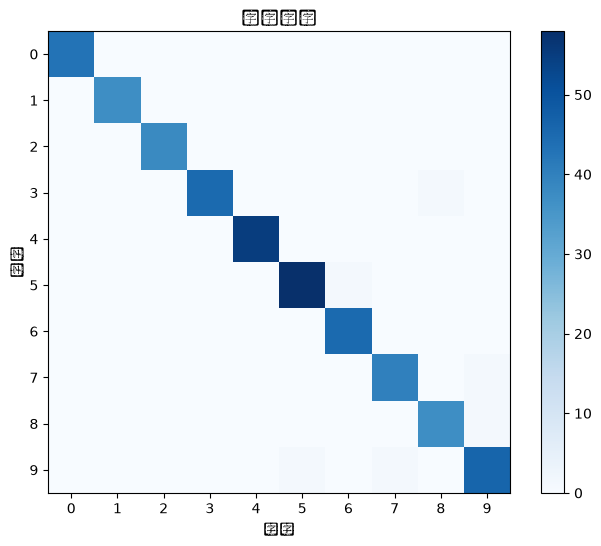

搞混的格子（去掉对角线后，数字=搞混的次数）：
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 1 0 0]]


In [6]:
# 第 5 步：画混淆矩阵
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel("预测")
plt.ylabel("真实")
plt.title("混淆矩阵")
plt.show()

# 把对角线（预测对的）清零，剩下的就是搞混的格子
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
print("搞混的格子（去掉对角线后，数字=搞混的次数）：")
print(cm_no_diag)

In [10]:
# 第 6 步：三个模型对比，看谁最适合这个数据
models = {
    "逻辑回归": LogisticRegression(max_iter=500),
    "SVM":      SVC(),
    "随机森林": RandomForestClassifier(),
}

for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"{name}: {acc:.2%}")

print("\n哪个最好？和鸢尾花那次比，为什么排名可能不一样？")

逻辑回归: 97.33%
SVM: 98.67%
随机森林: 97.56%

哪个最好？和鸢尾花那次比，为什么排名可能不一样？


## 埋一个引子：PCA 降到 2 维看「结构」

这 64 个像素里其实藏着规律：**同一个数字的不同写法，在空间里应该聚在一起**。

下面用 PCA 把 64 维硬压到 2 维画出来，颜色是真实数字。注意看：同一种颜色是不是大致聚成了一团？

**这就是无监督学习想自动干的事**——不给答案，让算法自己发现「谁和谁是一伙的」。

c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

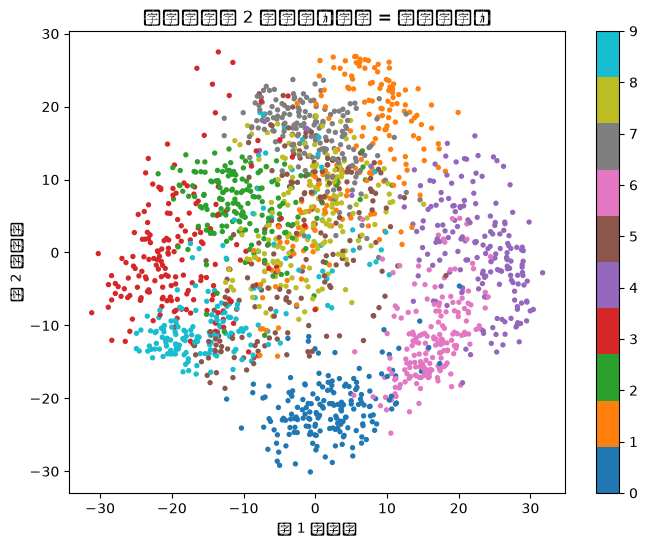

In [8]:
# 第 7 步：PCA 降到 2 维可视化
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="tab10", s=8)
plt.colorbar(scatter, ticks=range(10))
plt.title("手写数字的 2 维投影（颜色 = 真实数字）")
plt.xlabel("第 1 主成分")
plt.ylabel("第 2 主成分")
plt.show()

## 自己动手改（巩固练习）

1. 看第 5 步输出，**哪两个数字最容易搞混？**（比如 1 和 7？3 和 8？4 和 9？）想想为什么它们长得像。
2. 把 SVM 换成线性核：`SVC(kernel="linear")`，准确率怎么变？
3. 把 `test_size` 改成 `0.1` 和 `0.5`，这次准确率会变吗？（数据比鸢尾花多了，可能更明显）
4. 看第 7 步的 PCA 图，找找哪两类数字在平面上「黏在一起」分不开——它们是不是正好就是混淆矩阵里搞混的那对？

**练习 4 是个关键观察**：你已经亲眼看到「数据自己聚成团」了。下一步的无监督学习，就是让算法替你找到这些团。